### A visual tour and leakage-safe baseline on 211,834 NOAA laboratory samples

Florida red tide is caused by high concentrations of *Karenia brevis*. It can close beaches and shellfish beds, kill marine life, and expose coastal communities to airborne toxins.

This notebook asks a practical machine-learning question:

> **Given everything observed at a monitored coastal location today and during the recent past, will the cell count cross 100,000 cells/L in the next seven days?**

We will explore the measurements, see why the label requires special care, train a chronological baseline, and identify ways to improve it.

In [11]:
import os
os.getcwd()

'/home/jan/Dokumente/Neue Fische/Repositorys/Modul_03/mle-model-deployment-project/notebooks'

In [ ]:
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display, HTML
except ImportError:  # Makes the notebook testable in minimal Python runtimes.
    class HTML(str):
        pass
    def display(value):
        print(value)

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    roc_curve, confusion_matrix, f1_score, brier_score_loss
)
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', context='notebook')
COLORS = {'navy':'#071827', 'teal':'#12a4a6', 'red':'#ef5350', 'gold':'#f4b942', 'blue':'#3a86c8'}

ROOT = Path("../data/raw")

obs = pd.read_parquet(ROOT / "habsos_observations.parquet")
df = pd.read_parquet(ROOT / "early_warning_benchmark.parquet")
with open(ROOT / "feature_columns.txt") as f:
    features = [line.strip() for line in f]

print(f'Data root: {ROOT}')
print(f'Loaded {len(obs):,} observations and {len(df):,} forecast rows.')

TypeError: unsupported operand type(s) for +: 'PosixPath' and 'str'

## 1. The dataset in four numbers

The two main tables serve different purposes:

- `habsos_observations`: the cleaned scientific record, one row per laboratory sample;
- `early_warning_benchmark`: one row per monitored location-date eligible for a real 7-day forecast label.

In [2]:
cards = [
    ('LAB SAMPLES', f'{len(obs):,}', COLORS['red']),
    ('FORECAST ROWS', f'{len(df):,}', COLORS['teal']),
    ('7-DAY ONSETS', f"{int(df.target_bloom_next_7d.sum()):,}", COLORS['gold']),
    ('YEARS COVERED', f"{obs.date.dt.year.min()}–{obs.date.dt.year.max()}", COLORS['blue']),
]
html = '<div style="display:flex;gap:14px;flex-wrap:wrap">'
for label, value, color in cards:
    html += f'''<div style="background:#0d2638;color:white;padding:18px 22px;border-radius:12px;min-width:180px;border-top:5px solid {color}">
    <div style="font-size:30px;font-weight:700">{value}</div><div style="color:#b9ced8;font-size:12px">{label}</div></div>'''
html += '</div>'
display(HTML(html))

## 2. Where were samples collected?

The archive is dominated by Florida, but it also includes Texas, Alabama, and Mississippi. Red points are samples at or above the benchmark bloom threshold.

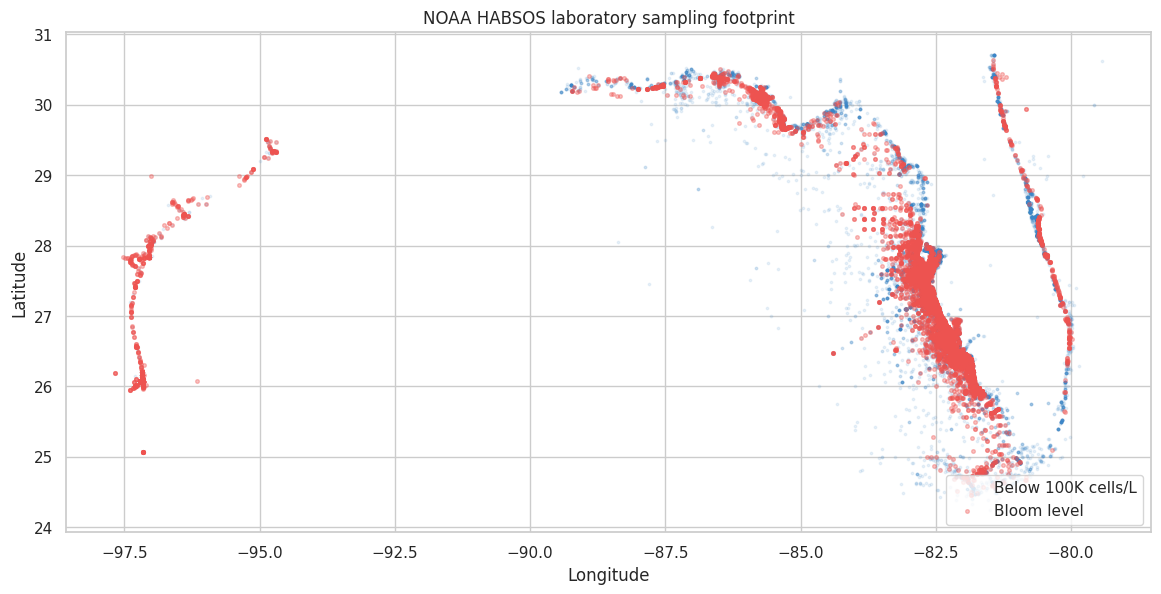

In [3]:
quiet = obs.loc[obs.is_bloom.eq(0)].sample(min(25_000, (obs.is_bloom == 0).sum()), random_state=42)
bloom = obs.loc[obs.is_bloom.eq(1)]

fig, ax = plt.subplots(figsize=(14, 6.5))
ax.scatter(quiet.longitude, quiet.latitude, s=3, alpha=.10, color=COLORS['blue'], label='Below 100K cells/L')
ax.scatter(bloom.longitude, bloom.latitude, s=7, alpha=.35, color=COLORS['red'], label='Bloom level')
ax.set(title='NOAA HABSOS laboratory sampling footprint', xlabel='Longitude', ylabel='Latitude')
ax.legend(frameon=True, loc='lower right')
plt.show()

## 3. What does “bloom level” mean?

HABSOS reports five concentration bands. For the forecasting task, **medium and high** counts are treated as bloom level:

| Severity | Cell count |
|---|---:|
| Not observed | 0 cells/L |
| Very low | 1–9,999 |
| Low | 10,000–99,999 |
| Medium | 100,000–999,999 |
| High | ≥1,000,000 |

The raw distribution spans many orders of magnitude, so log scaling is essential for visualization and regression.

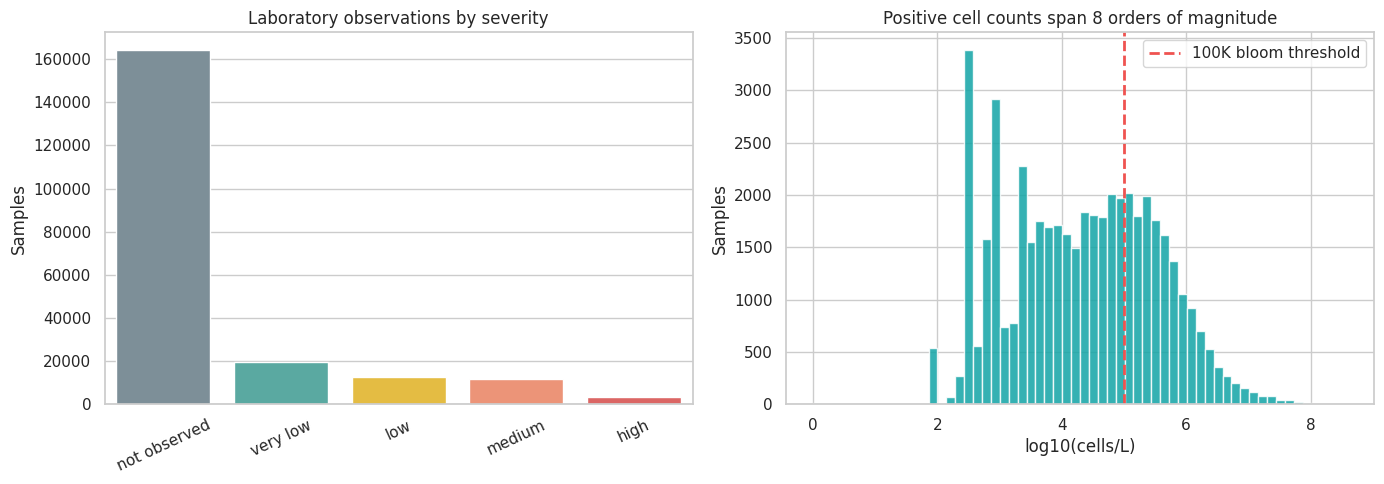

In [4]:
severity_order = ['not observed', 'very low', 'low', 'medium', 'high']
counts = obs.severity_label.value_counts().reindex(severity_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette=['#78909c','#4db6ac','#ffca28','#ff8a65','#ef5350'])
axes[0].set(title='Laboratory observations by severity', xlabel='', ylabel='Samples')
axes[0].tick_params(axis='x', rotation=25)

positive_counts = obs.loc[obs.cell_count > 0, 'cell_count']
axes[1].hist(np.log10(positive_counts), bins=60, color=COLORS['teal'], alpha=.85)
axes[1].axvline(np.log10(100_000), color=COLORS['red'], ls='--', lw=2, label='100K bloom threshold')
axes[1].set(title='Positive cell counts span 8 orders of magnitude', xlabel='log10(cells/L)', ylabel='Samples')
axes[1].legend()
plt.tight_layout(); plt.show()

## 4. The label is the most important part

A tempting approach is to generate a daily coastal grid and call every location without a bloom report `0`. That would be wrong:

> **No sample does not mean no bloom.**

This benchmark keeps a location-date only when the same 0.1° monitoring cell has at least one real follow-up sample during days 1–7. Every retained row begins below 100,000 cells/L, making this an onset/escalation forecast rather than a contemporaneous detector.

Historical features are strictly earlier than the row date. Future observation counts are included only as target-audit columns and are excluded from `feature_columns.txt`.

In [5]:
audit = pd.DataFrame({
    'check': [
        'Rows with observed follow-up in next 7 days',
        'Rows already at bloom level today',
        'Duplicate row IDs',
        'Target columns inside model feature list',
    ],
    'value': [
        int(df.target_observation_days_next_7d.gt(0).sum()),
        int(df.current_is_bloom.sum()),
        int(df.row_id.duplicated().sum()),
        sum(c.startswith('target_') for c in features),
    ]
})
display(audit)

,check,value
0,Rows with observed follow-up in next 7 days,45631
1,Rows already at bloom level today,0
2,Duplicate row IDs,0
3,Target columns inside model feature list,0


## 5. Red tide is strongly seasonal

Seasonality is useful, but it is not enough: monitoring effort changes over time, and true blooms depend on transport, temperature, nutrients, and prior regional activity.

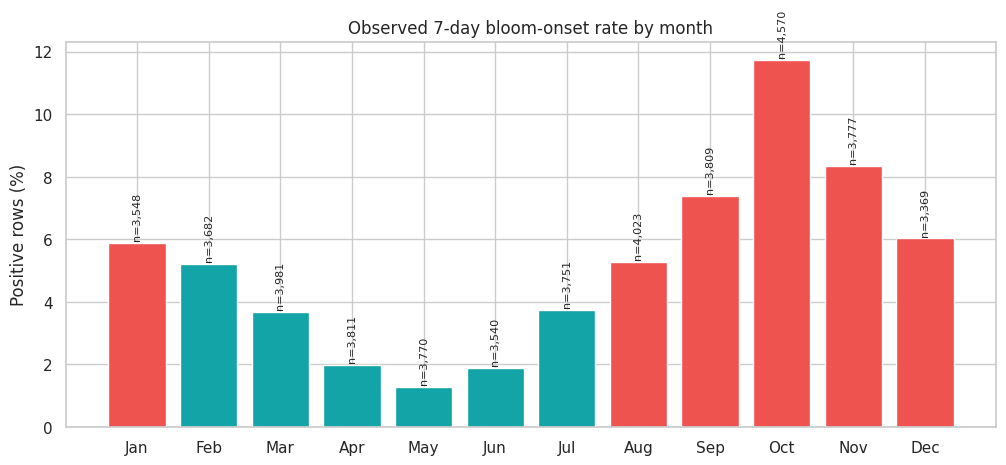

In [6]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('month').target_bloom_next_7d.agg(['mean','size','sum']).reindex(range(1,13))

fig, ax = plt.subplots(figsize=(12, 5))
colors = [COLORS['red'] if value >= monthly['mean'].median() else COLORS['teal'] for value in monthly['mean']]
ax.bar(month_names, monthly['mean'] * 100, color=colors)
ax.set(title='Observed 7-day bloom-onset rate by month', xlabel='', ylabel='Positive rows (%)')
for i, row in enumerate(monthly.itertuples()):
    ax.text(i, row.mean * 100 + .15, f'n={row.size:,}', ha='center', fontsize=8, rotation=90)
plt.show()

## 6. Why the supplied time split matters

Randomly mixing neighboring dates would leak very similar bloom episodes into both training and validation. The official split mimics deployment into future years:

- **Train:** 2000–2018
- **Validation:** 2019–2021
- **Test:** 2022–2024

,start,end,rows,positives,positive_rate
split,,,,,
train,2000-01-03,2018-12-31,32304,1940,6.01%
validation,2019-01-01,2021-12-30,8668,344,3.97%
test,2022-01-02,2024-03-20,4659,140,3.00%


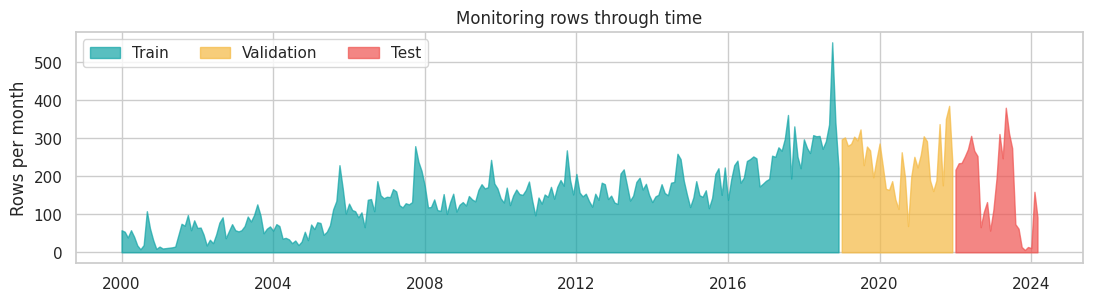

In [7]:
split_summary = df.groupby('split', sort=False).agg(
    start=('date','min'), end=('date','max'), rows=('row_id','size'),
    positives=('target_bloom_next_7d','sum'), positive_rate=('target_bloom_next_7d','mean')
)
split_summary['positive_rate'] = split_summary['positive_rate'].map(lambda x: f'{x:.2%}')
display(split_summary)

fig, ax = plt.subplots(figsize=(13, 3))
palette = {'train':COLORS['teal'], 'validation':COLORS['gold'], 'test':COLORS['red']}
for split, group in df.groupby('split', sort=False):
    yearly = group.groupby(group.date.dt.to_period('M')).size()
    dates = yearly.index.to_timestamp()
    ax.fill_between(dates, yearly.values, alpha=.70, color=palette[split], label=split.title())
ax.set(title='Monitoring rows through time', xlabel='', ylabel='Rows per month')
ax.legend(ncol=3); plt.show()

## 7. A strong, CPU-friendly baseline

We use the 49 numeric predictors listed by the dataset, median imputation fitted only on training data, class balancing, and histogram gradient boosting. The classification threshold is selected on validation data and then frozen for the test period.

Because only about 3% of test rows are positive, **PR-AUC is the primary metric**. Accuracy would reward a useless model that almost always predicts “no bloom.”

In [8]:
target = 'target_bloom_next_7d'
train = df.split.eq('train')
valid = df.split.eq('validation')
test = df.split.eq('test')

model = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('classifier', HistGradientBoostingClassifier(
        learning_rate=.06, max_iter=250, max_leaf_nodes=31,
        min_samples_leaf=30, l2_regularization=1.0,
        class_weight='balanced', random_state=42
    ))
])
model.fit(df.loc[train, features], df.loc[train, target])

p_valid = model.predict_proba(df.loc[valid, features])[:, 1]
precision, recall, thresholds = precision_recall_curve(df.loc[valid, target], p_valid)
f1_values = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
threshold = float(thresholds[np.nanargmax(f1_values)])
p_test = model.predict_proba(df.loc[test, features])[:, 1]

def metrics(y, p):
    return {
        'PR-AUC': average_precision_score(y, p),
        'ROC-AUC': roc_auc_score(y, p),
        'Brier': brier_score_loss(y, p),
        'F1': f1_score(y, p >= threshold),
    }

results = pd.DataFrame({
    'Validation': metrics(df.loc[valid,target], p_valid),
    'Test': metrics(df.loc[test,target], p_test),
}).T
print(f'Validation-selected decision threshold: {threshold:.3f}')
display(results.round(3))

Validation-selected decision threshold: 0.683


,PR-AUC,ROC-AUC,Brier,F1
Validation,0.306,0.913,0.073,0.425
Test,0.347,0.955,0.041,0.425


## 8. Curves and alert trade-offs

A warning system must balance missed blooms against false alerts. The threshold shown in the confusion matrix maximizes validation F1; real applications should instead choose a threshold from an explicit alert budget.

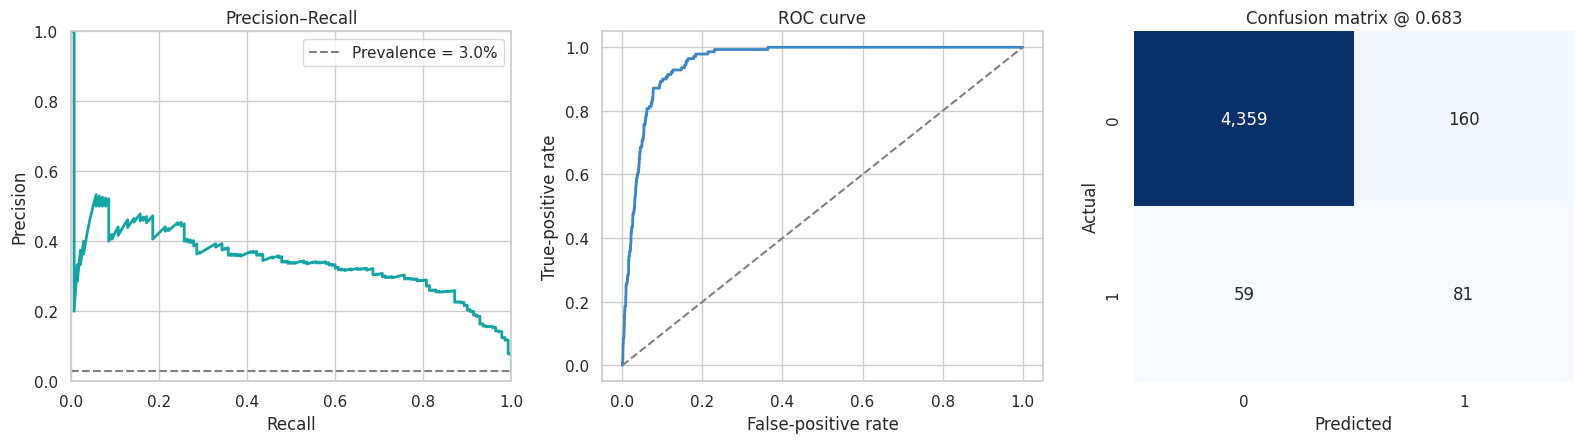

In [9]:
y_test = df.loc[test, target].to_numpy()
pr, rc, _ = precision_recall_curve(y_test, p_test)
fpr, tpr, _ = roc_curve(y_test, p_test)
cm = confusion_matrix(y_test, p_test >= threshold)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
axes[0].plot(rc, pr, color=COLORS['teal'], lw=2)
axes[0].axhline(y_test.mean(), color='gray', ls='--', label=f'Prevalence = {y_test.mean():.1%}')
axes[0].set(title='Precision–Recall', xlabel='Recall', ylabel='Precision', xlim=(0,1), ylim=(0,1)); axes[0].legend()

axes[1].plot(fpr, tpr, color=COLORS['blue'], lw=2)
axes[1].plot([0,1],[0,1], color='gray', ls='--')
axes[1].set(title='ROC curve', xlabel='False-positive rate', ylabel='True-positive rate')

sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', cbar=False, ax=axes[2])
axes[2].set(title=f'Confusion matrix @ {threshold:.3f}', xlabel='Predicted', ylabel='Actual')
plt.tight_layout(); plt.show()

## 9. Which signals matter most?

Permutation importance measures how much test PR-AUC drops when one input is shuffled. This is predictive importance—not a causal explanation—and correlated history variables can share importance.

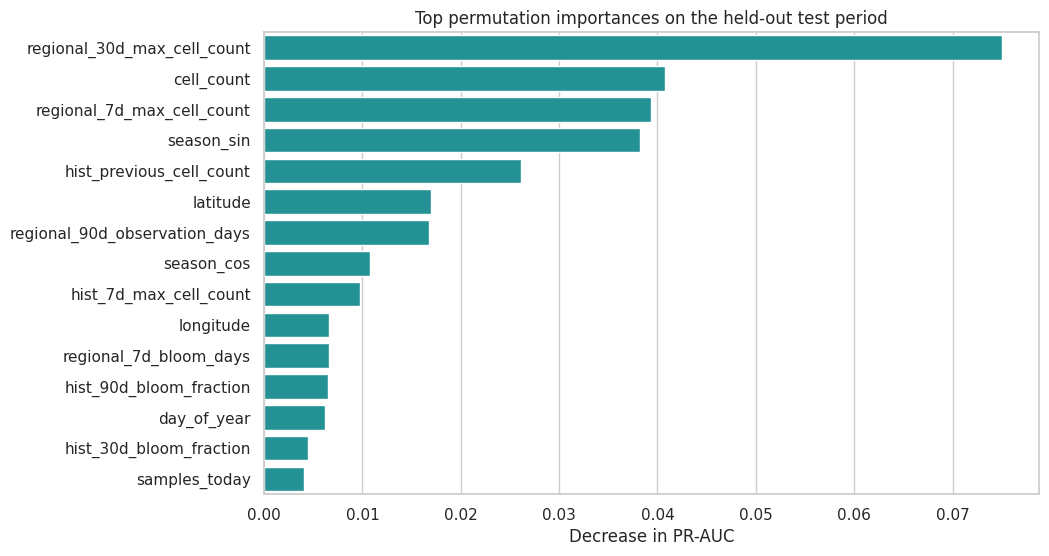

In [10]:
sample = df.loc[test].sample(min(2_000, test.sum()), random_state=42)
importance = permutation_importance(
    model, sample[features], sample[target], scoring='average_precision',
    n_repeats=3, random_state=42, n_jobs=1
)
importance_df = pd.DataFrame({'feature':features, 'importance':importance.importances_mean})    .sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df, y='feature', x='importance', color=COLORS['teal'], ax=ax)
ax.set(title='Top permutation importances on the held-out test period', xlabel='Decrease in PR-AUC', ylabel='')
plt.show()

### Takeaway

The most important feature of this dataset is not its row count. It is the labelling rule: **unknown water remains unknown**. That makes the benchmark harder, but much closer to the real early-warning problem.